In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import sys

sys.path.append(str(Path("../src").resolve()))

from config import (
    RAW_ROOT,
    GROUP3_PATIENTS,
    BAD_FILES,
    CHANNEL_ORDER,
    NOTCH_FREQ,
    LOW_FREQ,
    HIGH_FREQ,
    WINDOW_SIZE_SEC,
    STEP_SEC,
    BAD_CHANNEL_Z_THRESH
)

from utils import (
    load_raw_edf,
    prepare_raw,
    apply_filters,
    parse_chbmit_summary,
    detect_bad_channels,
    reorder_channels,
    zscore_normalize,
    create_windows_and_labels,
    plot_grouped_channel_comparison,
    plot_raw_vs_normalized_signal,
    plot_suspicious_channels,
    plot_psd_before_after
)



In [2]:
group3_valid_edf_files = []
group3_skipped_known_bad = []

print("Checking Group 3 files...")
print(f"Group 3 patients: {GROUP3_PATIENTS}")

for patient_name in GROUP3_PATIENTS:
    
    print(f"Patient: {patient_name}")

    patient_folder = RAW_ROOT / patient_name
    edf_files = sorted(patient_folder.glob("*.edf"))
    patient_bad_files = BAD_FILES.get(patient_name, [])

    print(f"Found {len(edf_files)} EDF files")
    print(f"Known bad files: {patient_bad_files}")

    for file_path in edf_files:
        file_name = file_path.name

        if file_name in patient_bad_files:
            print(f"Skipping known bad file: {file_name}")
            group3_skipped_known_bad.append({
                "patient_name": patient_name,
                "file_name": file_name,
                "reason": "known bad file"
            })
            continue

        group3_valid_edf_files.append(file_path)


print(f"Total valid EDF files in Group 3 after skipping known bad files: {len(group3_valid_edf_files)}")

Checking Group 3 files...
Group 3 patients: ['chb16', 'chb17']
Patient: chb16
Found 19 EDF files
Known bad files: ['chb16_16.edf', 'chb16_17.edf']
Skipping known bad file: chb16_16.edf
Skipping known bad file: chb16_17.edf
Patient: chb17
Found 21 EDF files
Known bad files: ['chb17_12.edf']
Total valid EDF files in Group 3 after skipping known bad files: 38


In [3]:
if len(group3_valid_edf_files) == 0:
    raise ValueError("No valid EDF files found in Group 3 after skipping known bad files.")

# Use first valid file as reference
first_raw = load_raw_edf(group3_valid_edf_files[0])
first_raw = prepare_raw(first_raw)
reference_channels = first_raw.ch_names.copy()

group3_global_common = set(reference_channels)

for file_path in group3_valid_edf_files[1:]:
    raw_tmp = load_raw_edf(file_path)
    raw_tmp = prepare_raw(raw_tmp)
    current_channels = set(raw_tmp.ch_names)
    group3_global_common = group3_global_common.intersection(current_channels)

# Order channels like standard order as much as possible
group3_expected_channels = [ch for ch in CHANNEL_ORDER if ch in group3_global_common]

# Add extra channels that are common but not already in CHANNEL_ORDER
extra_common_channels = [
    ch for ch in reference_channels
    if ch in group3_global_common and ch not in group3_expected_channels
]
group3_expected_channels.extend(extra_common_channels)

print("Global common channels across valid Group 3 files:")
print(group3_expected_channels)
print(f"Number of Group 3 common channels: {len(group3_expected_channels)}")

C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8', '-'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8', '-'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Channel names are not unique, found duplicates

Global common channels across valid Group 3 files:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', '--0', '--1', '--2', '--3']
Number of Group 3 common channels: 21


In [4]:
group3_channel_check_rows = []

for file_path in group3_valid_edf_files:
    patient_name = file_path.parent.name
    file_name = file_path.name

    raw = load_raw_edf(file_path)
    raw = prepare_raw(raw)

    group3_channel_check_rows.append({
        "patient_name": patient_name,
        "file_name": file_name,
        "n_channels_before": len(raw.ch_names),
        "channels_before": ", ".join(raw.ch_names),
        "n_common_channels_available": sum(ch in raw.ch_names for ch in group3_expected_channels)
    })

df_group3_channel_check = pd.DataFrame(group3_channel_check_rows)
print(df_group3_channel_check[["patient_name", "file_name", "n_channels_before", "n_common_channels_available"]])

C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8', '-'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8', '-'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Scaling factor is not defined in following channels:
--0, --1, --2, --3, --4
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:20: RuntimeWarning: Channel names are not unique, found duplicates

   patient_name      file_name  n_channels_before  n_common_channels_available
0         chb16   chb16_01.edf                 28                           21
1         chb16   chb16_02.edf                 28                           21
2         chb16   chb16_03.edf                 28                           21
3         chb16   chb16_04.edf                 28                           21
4         chb16   chb16_05.edf                 28                           21
5         chb16   chb16_06.edf                 28                           21
6         chb16   chb16_07.edf                 28                           21
7         chb16   chb16_08.edf                 28                           21
8         chb16   chb16_09.edf                 28                           21
9         chb16   chb16_10.edf                 28                           21
10        chb16   chb16_11.edf                 28                           21
11        chb16   chb16_12.edf                 28   

In [8]:
display(df_group3_channel_check)

df_group3_summary = df_group3_channel_check.groupby("patient_name").agg(
    n_files=("file_name", "count"),
    avg_channels_before=("n_channels_before", "mean"),
    min_channels_before=("n_channels_before", "min"),
    max_channels_before=("n_channels_before", "max"),
    avg_common_channels_available=("n_common_channels_available", "mean"),
    min_common_channels_available=("n_common_channels_available", "min"),
    max_common_channels_available=("n_common_channels_available", "max")
).reset_index()

display(df_group3_summary)

,patient_name,file_name,n_channels_before,channels_before,n_common_channels_available
0,chb16,chb16_01.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
1,chb16,chb16_02.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
2,chb16,chb16_03.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
3,chb16,chb16_04.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
4,chb16,chb16_05.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
5,chb16,chb16_06.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
6,chb16,chb16_07.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
7,chb16,chb16_08.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
8,chb16,chb16_09.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21
9,chb16,chb16_10.edf,28,"FP1-F7, F7-T7, T7-P7, P7-O1, --0, FP1-F3, F3-C...",21


,patient_name,n_files,avg_channels_before,min_channels_before,max_channels_before,avg_common_channels_available,min_common_channels_available,max_common_channels_available
0,chb16,17,27.294118,22,28,21.0,21,21
1,chb17,21,27.714286,22,28,21.0,21,21


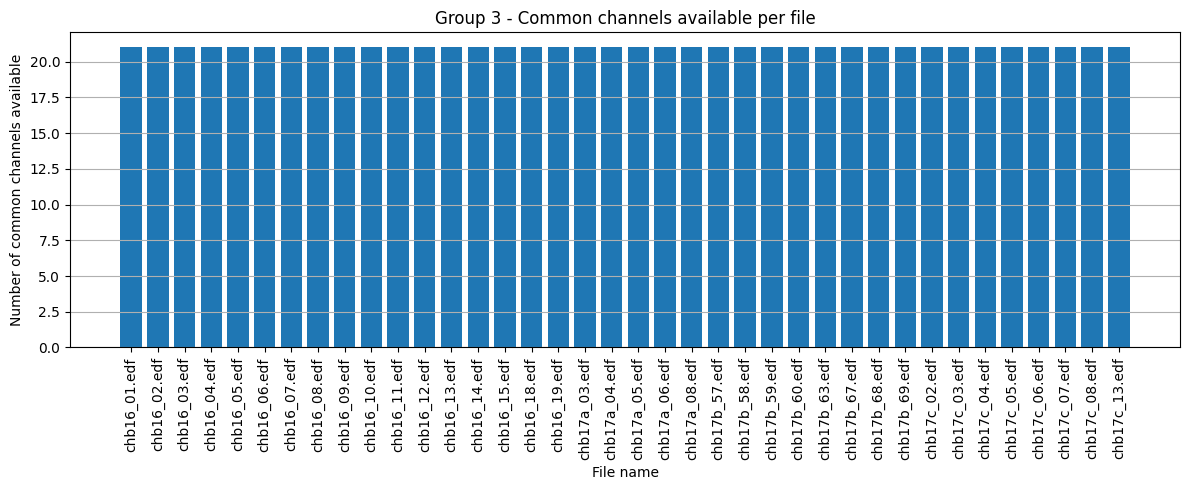

C:\Users\MSI\Desktop\EEG_FYP\data\raw\chb16\chb16_01.edf


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(df_group3_channel_check["file_name"], df_group3_channel_check["n_common_channels_available"])
plt.xticks(rotation=90)
plt.xlabel("File name")
plt.ylabel("Number of common channels available")
plt.title("Group 3 - Common channels available per file")
plt.grid(axis="y")
plt.tight_layout()
plt.show()



In [ ]:
#checking the final common channels of g3 after processing


from config import BAD_FILES, CHANNEL_ORDER
from utils import load_raw_edf, prepare_raw

group3_valid_edf_files = []


for patient_name in GROUP3_PATIENTS:
    patient_folder = RAW_ROOT / patient_name
    edf_files = sorted(patient_folder.glob("*.edf"))
    patient_bad_files = set(BAD_FILES.get(patient_name, []))

    for file_path in edf_files:
        if file_path.name not in patient_bad_files:
            group3_valid_edf_files.append(file_path)

print(f"Number of valid Group 3 files: {len(group3_valid_edf_files)}")

if len(group3_valid_edf_files) == 0:
    raise ValueError("No valid Group 3 files found.")

first_raw = load_raw_edf(group3_valid_edf_files[0])
first_raw = prepare_raw(first_raw)
reference_channels = first_raw.ch_names.copy()

group3_common_set = set(reference_channels)

for file_path in group3_valid_edf_files[1:]:
    raw = load_raw_edf(file_path)
    raw = prepare_raw(raw)
    current_set = set(raw.ch_names)
    group3_common_set = group3_common_set.intersection(current_set)

group3_common_ordered = [ch for ch in CHANNEL_ORDER if ch in group3_common_set]

extra_channels = [
    ch for ch in reference_channels
    if ch in group3_common_set and ch not in group3_common_ordered
]
group3_common_ordered.extend(extra_channels)

print("Group 3 common channels after skipping bad files:")
print(f"Count: {len(group3_common_ordered)}")
print(group3_common_ordered)